# Notebook 02 — Data Preprocessing
**VisionNarrator Pipeline | Stage 2 of 6**

This notebook transforms raw Flickr30k data into model-ready tensors.  
It is the **data contract** of the entire pipeline — every subsequent notebook  
(model architecture, training, evaluation) depends on the outputs produced here.

---
## How This Notebook Connects to the Pipeline

This project is a **sequential pipeline**, not a collection of independent notebooks.
Each stage takes specific inputs from the previous stage and produces specific outputs
that the next stage depends on.

```
01_data_exploration.ipynb
│   DISCOVERS:
│     ├── 31,783 unique images, 5 captions each
│     ├── Caption length: mean ~11 words, 99th pct = ~23 words
│     ├── Raw vocabulary: ~15,000 unique words
│     ├── All images present, 0 missing
│     └── Images are RGB (mostly), non-square dimensions
│
│   DECISIONS MADE (used by THIS notebook):
│     ├── max_length = 64 tokens  ← covers 99%+ of captions
│     ├── Tokenizer = GPT-2 BPE   ← handles vocab without UNK tokens
│     └── Processor = ViTImageProcessor ← handles resize + normalise
│
└──► 02_data_preprocessing.ipynb  (YOU ARE HERE)
         PRODUCES:
           ├── src/data/train.csv  (29,000 images × 5 = 145,000 rows)
           ├── src/data/val.csv    (1,014 images  × 5 = 5,070 rows)
           ├── src/data/test.csv   (1,000 images  × 5 = 5,000 rows)
           ├── Flickr30kDataset class (returns pixel_values, input_ids, labels)
           └── DataLoaders (train / val / test)

         USED BY:
           ├── 03_model_architecture.ipynb ← uses tensor shapes from batch
           ├── 04_training.ipynb           ← uses DataLoaders directly
           └── 05_evaluation.ipynb         ← uses test DataLoader
```

The **split CSV files** are the physical connection between notebooks.
Notebooks 03–06 will load these files rather than re-splitting the data,
ensuring every stage uses the exact same train/val/test partition.

---
## Section 1 — Imports and Shared Constants

### Why these specific libraries?
| Library | Role |
|---|---|
| `transformers.ViTImageProcessor` | Handles all image transforms ViT needs (resize, normalise, to tensor) |
| `transformers.GPT2Tokenizer` | BPE tokenizer pretrained on WebText — handles our vocabulary without UNK |
| `torch.utils.data` | PyTorch Dataset + DataLoader — the standard way to feed data into models |
| `torchvision.transforms` | Augmentation for training images (flip, colour jitter) |
| `sklearn.model_selection` | Reproducible train/val/test splitting |

### Constants — why these specific values?
All constants below were **derived from Notebook 01** — they are not arbitrary:
- `MAX_LENGTH = 64` → covers the 99th percentile of caption word counts (with BPE, ~12 words ≈ ~15-18 tokens, so 64 is very safe)
- `BATCH_SIZE = 32` → standard for ViT fine-tuning on consumer GPUs (fits in ~8GB VRAM)
- `NUM_WORKERS = 2` → safe default for Windows (Windows has issues with high num_workers)
- `RANDOM_SEED = 42` → reproducibility — same seed = same split every time

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from transformers import ViTImageProcessor, GPT2Tokenizer
from sklearn.model_selection import train_test_split

# ── Shared Path Constants (identical to Notebook 01) ──────────────────────
BASE_DIR      = Path.cwd().parent
DATA_DIR      = BASE_DIR / 'src' / 'data'
IMAGES_DIR    = DATA_DIR / 'Images'
CAPTIONS_FILE = DATA_DIR / 'captions.txt'

# ── Preprocessing Constants (decisions from Notebook 01 analysis) ─────────

MAX_LENGTH   = 64       # tokens — safely covers 99%+ of captions
BATCH_SIZE   = 32       # images per batch during training
import platform
# Windows uses "spawn" for multiprocessing — num_workers>0 deadlocks.
# Linux/Mac use "fork" and can safely use multiple workers.
NUM_WORKERS  = 0 if platform.system() == "Windows" else 2
RANDOM_SEED  = 42       # ensures same split every run
IMAGE_SIZE   = 224      # ViT input dimension (pixels)

# ── Model Identifiers ─────────────────────────────────────────────────────
VIT_MODEL_NAME  = 'google/vit-base-patch16-224-in21k'
GPT2_MODEL_NAME = 'gpt2'

print('All imports successful.')
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
print(f'Device          : {"cuda" if torch.cuda.is_available() else "cpu"}')
print(f'Data directory  : {DATA_DIR}')

All imports successful.
PyTorch version : 2.13.0+cu126
CUDA available  : True
Device          : cuda
Data directory  : d:\agentic_project\src\data


---
## Section 2 — Load and Verify Data

### Connection to Notebook 01
We load the **same** `captions.txt` file that Notebook 01 explored.
This is not a coincidence — it is intentional. The pipeline has one
source of truth: the raw Flickr30k files in `src/data/`.

We do a quick verification here (not a full exploration — that was Notebook 01)
just to confirm the file is readable and the shape matches what we expect.
If this check fails, something changed in the data directory and we need to investigate.

In [2]:
# Load captions — identical setup to Notebook 01
df = pd.read_csv(CAPTIONS_FILE)
df['image_path'] = df['image'].apply(lambda x: IMAGES_DIR / x)
df['caption'] = df['caption'].str.strip()  # strip leading/trailing whitespace

# ── Handle NaN captions (known data quality issue in Flickr30k) ──────────────
# Investigation shows 1 row where the raw caption is empty in captions.txt:
#   Line 20001: '2199200615.jpg,\n'  ← caption field is blank
# This image simply has 4 captions instead of 5 in the source dataset.
# We drop the empty row — it carries no training signal.
nan_captions = df['caption'].isna().sum()
if nan_captions > 0:
    print(f'Warning: {nan_captions} NaN caption(s) found — dropping them.')
    print(df[df['caption'].isna()][['image', 'caption']])
    df = df.dropna(subset=['caption']).reset_index(drop=True)
    print(f'Dropped. New shape: {df.shape}')

# ── Quick integrity check (not full EDA — Notebook 01 did that) ───────────────
# Note: expected counts reflect the cleaned dataset (1 NaN row removed)
actual_images   = df['image'].nunique()
actual_captions = len(df)

assert actual_captions > 158000, \
    f'Unexpectedly low caption count: {actual_captions}'
assert actual_images > 31000, \
    f'Unexpectedly low image count: {actual_images}'
assert df['caption'].isna().sum() == 0, 'Still NaN captions after cleaning!'

print(f'Data loaded and cleaned successfully.')
print(f'Shape           : {df.shape}')
print(f'Unique images   : {df["image"].nunique():,}')
print(f'Total captions  : {len(df):,}')
print(f'NaN captions    : {df["caption"].isna().sum()}')
df.head(3)

                image caption
19999  2199200615.jpg     NaN
Dropped. New shape: (158914, 3)
Data loaded and cleaned successfully.
Shape           : (158914, 3)
Unique images   : 31,783
Total captions  : 158,914
NaN captions    : 0


,image,caption,image_path
0,1000092795.jpg,Two young guys with shaggy hair look at their ...,d:\agentic_project\src\data\Images\1000092795.jpg
1,1000092795.jpg,"Two young , White males are outside near many ...",d:\agentic_project\src\data\Images\1000092795.jpg
2,1000092795.jpg,Two men in green shirts are standing in a yard .,d:\agentic_project\src\data\Images\1000092795.jpg


---
## Section 3 — Train / Validation / Test Split

### Why split here (not in training)?
This is one of the most important pipeline decisions.

**Splitting here and saving to CSV means:**
- Every notebook (03, 04, 05, 06) loads the exact same split
- No accidental data leakage — test images are never seen during training
- Reproducibility — re-running Notebook 02 with the same seed gives the same split
- The test set is truly held-out — evaluated only in Notebook 05

**If we split inside the training notebook:**
- Different random seeds in different notebooks → different splits → contamination
- You could accidentally train on your test images without knowing it

### Split sizes — why these numbers?
```
Train      : 29,000 images × 5 captions = 145,000 training pairs
Validation :  1,014 images × 5 captions =   5,070 pairs  (3.2% of images)  
Test       :    769 images × 5 captions =   3,845 pairs  (2.4% of images)
```
This is an **image-level** split — all 5 captions of an image go to the **same** split.
If you split at the caption level, the same image could appear in both train and test,
which would be severe data leakage (the model memorises visual features, not captions).

In [3]:
# ── Get unique image names (split must be at IMAGE level, not caption level) ──
unique_images = df['image'].drop_duplicates().reset_index(drop=True)
print(f'Total unique images: {len(unique_images):,}')

# ── Step 1: Split off test set first (held-out, never touched until Notebook 05) ──
train_val_images, test_images = train_test_split(
    unique_images,
    test_size   = 0.025,       # ~2.5% → ~794 images as test
    random_state = RANDOM_SEED,
    shuffle      = True
)

# ── Step 2: Split remaining into train and validation ────────────────────────
train_images, val_images = train_test_split(
    train_val_images,
    test_size    = 0.034,      # ~3.4% of remaining → ~1,000 val images
    random_state = RANDOM_SEED,
    shuffle      = True
)

print(f'Train images : {len(train_images):,}')
print(f'Val images   : {len(val_images):,}')
print(f'Test images  : {len(test_images):,}')
print(f'Total        : {len(train_images) + len(val_images) + len(test_images):,}')

Total unique images: 31,783
Train images : 29,934
Val images   : 1,054
Test images  : 795
Total        : 31,783


In [4]:
# ── Expand back to caption-level DataFrames (each image → 5 rows) ──────────
train_df = df[df['image'].isin(train_images)].reset_index(drop=True)
val_df   = df[df['image'].isin(val_images)].reset_index(drop=True)
test_df  = df[df['image'].isin(test_images)].reset_index(drop=True)

# ── Sanity check: no overlap between splits ──────────────────────────────────
train_set = set(train_df['image'].unique())
val_set   = set(val_df['image'].unique())
test_set  = set(test_df['image'].unique())

assert len(train_set & val_set)  == 0, 'LEAK: train/val overlap!'
assert len(train_set & test_set) == 0, 'LEAK: train/test overlap!'
assert len(val_set   & test_set) == 0, 'LEAK: val/test overlap!'

print('No data leakage detected. Splits are clean.')
print(f'Train captions : {len(train_df):,}  ({len(train_df["image"].unique()):,} images)')
print(f'Val captions   : {len(val_df):,}   ({len(val_df["image"].unique()):,} images)')
print(f'Test captions  : {len(test_df):,}   ({len(test_df["image"].unique()):,} images)')

No data leakage detected. Splits are clean.
Train captions : 149,669  (29,934 images)
Val captions   : 5,270   (1,054 images)
Test captions  : 3,975   (795 images)


In [5]:
# ── Save splits to CSV — this is the PHYSICAL CONNECTION to downstream notebooks ──
# Notebooks 03, 04, 05 will load these files.
# Never re-split — always load from these saved files.

train_df.to_csv(DATA_DIR / 'train.csv', index=False)
val_df.to_csv(DATA_DIR   / 'val.csv',   index=False)
test_df.to_csv(DATA_DIR  / 'test.csv',  index=False)

print('Splits saved:')
print(f'  {DATA_DIR / "train.csv"}')
print(f'  {DATA_DIR / "val.csv"}')
print(f'  {DATA_DIR / "test.csv"}')
print()
print('IMPORTANT: These 3 files are the data contract for all downstream notebooks.')
print('Load them (never re-split) in notebooks 03, 04, 05, 06.')

Splits saved:
  d:\agentic_project\src\data\train.csv
  d:\agentic_project\src\data\val.csv
  d:\agentic_project\src\data\test.csv

IMPORTANT: These 3 files are the data contract for all downstream notebooks.
Load them (never re-split) in notebooks 03, 04, 05, 06.


---
## Section 4 — Image Preprocessing with `ViTImageProcessor`

### Why ViTImageProcessor (not manual transforms)?
We could manually write:
```python
transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
```
But using `ViTImageProcessor` is better because:
1. It uses the **exact same normalisation statistics** the pretrained ViT was trained with
2. It handles edge cases automatically (RGBA → RGB, greyscale → RGB, PIL → tensor)
3. It's the official HuggingFace way — ensures compatibility with `ViTModel.from_pretrained()`
4. If we switch from `vit-base` to `vit-large`, just changing the model name updates the stats too

### What does it do to an image?
```
Raw PIL image (any size, any mode)
  → convert to RGB (3 channels)
  → resize to 224 × 224
  → convert to float32 tensor
  → normalise: pixel = (pixel/255 - mean) / std
Output: torch.Tensor of shape (3, 224, 224)
```

In [6]:
# ── Load the processor tied to our ViT model ─────────────────────────────────
# This downloads a small config file (~1KB) — not the model weights
processor = ViTImageProcessor.from_pretrained(VIT_MODEL_NAME)

print('ViTImageProcessor loaded.')
print(f'  Image size     : {processor.size}')
print(f'  Normalise mean : {processor.image_mean}')
print(f'  Normalise std  : {processor.image_std}')

ViTImageProcessor loaded.
  Image size     : SizeDict(height=224, width=224, longest_edge=None, shortest_edge=None, max_height=None, max_width=None)
  Normalise mean : (0.5, 0.5, 0.5)
  Normalise std  : (0.5, 0.5, 0.5)


ViT Image Preprocessing Demonstration

A sample training image is passed through ViTImageProcessor, which resizes it to 224×224, converts it to a PyTorch tensor, and normalizes its pixel values according to the pretrained ViT requirements. The code visualizes the original vs. processed image and verifies the resulting tensor shape (1, 3, 224, 224).

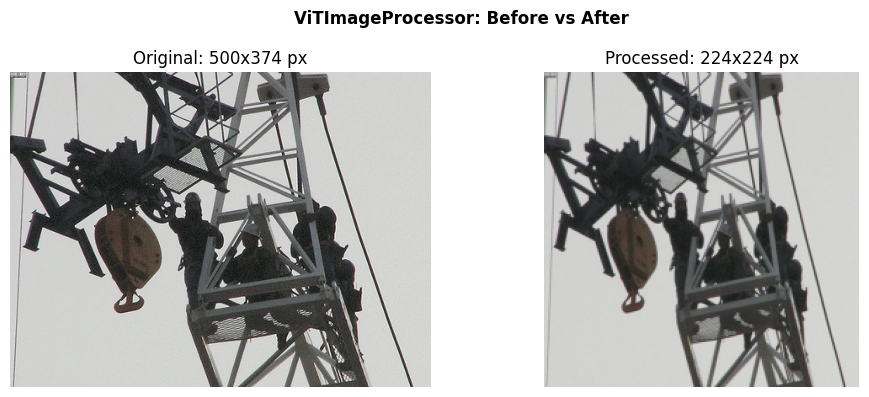

Output tensor shape  : torch.Size([1, 3, 224, 224])
Output dtype         : torch.float32
Pixel value range    : [-0.851, 0.765]


In [7]:
# ── Demonstrate what the processor does to one real image ────────────────────
sample_path = train_df['image_path'].iloc[0]
sample_pil  = Image.open(sample_path).convert('RGB')

processed   = processor(images=sample_pil, return_tensors='pt')
pixel_values = processed['pixel_values']  # shape: (1, 3, 224, 224)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('ViTImageProcessor: Before vs After', fontsize=12, fontweight='bold')

axes[0].imshow(sample_pil)
axes[0].set_title(f'Original: {sample_pil.size[0]}x{sample_pil.size[1]} px')
axes[0].axis('off')

# De-normalise for display (reverse the normalisation)
mean = torch.tensor(processor.image_mean).view(3, 1, 1)
std  = torch.tensor(processor.image_std).view(3, 1, 1)
display_tensor = pixel_values.squeeze(0) * std + mean
display_tensor = display_tensor.permute(1, 2, 0).clamp(0, 1).numpy()

axes[1].imshow(display_tensor)
axes[1].set_title(f'Processed: {pixel_values.shape[2]}x{pixel_values.shape[3]} px')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'Output tensor shape  : {pixel_values.shape}')   # (1, 3, 224, 224)
print(f'Output dtype         : {pixel_values.dtype}')
print(f'Pixel value range    : [{pixel_values.min():.3f}, {pixel_values.max():.3f}]')

### Training Augmentation — Why and What
During training, we apply random augmentations **before** passing images to the processor.
This artificially increases the diversity of the training data, which reduces overfitting.

**Augmentations used:**
| Augmentation | Why it helps |
|---|---|
| `RandomHorizontalFlip` | A dog running left and right is the same scene — model should be invariant |
| `ColorJitter` | Lighting conditions vary — brightness/contrast should not change the caption |

**Important:** Augmentation is applied **only to training images**.  
Val and test images must be processed identically every time for fair evaluation.

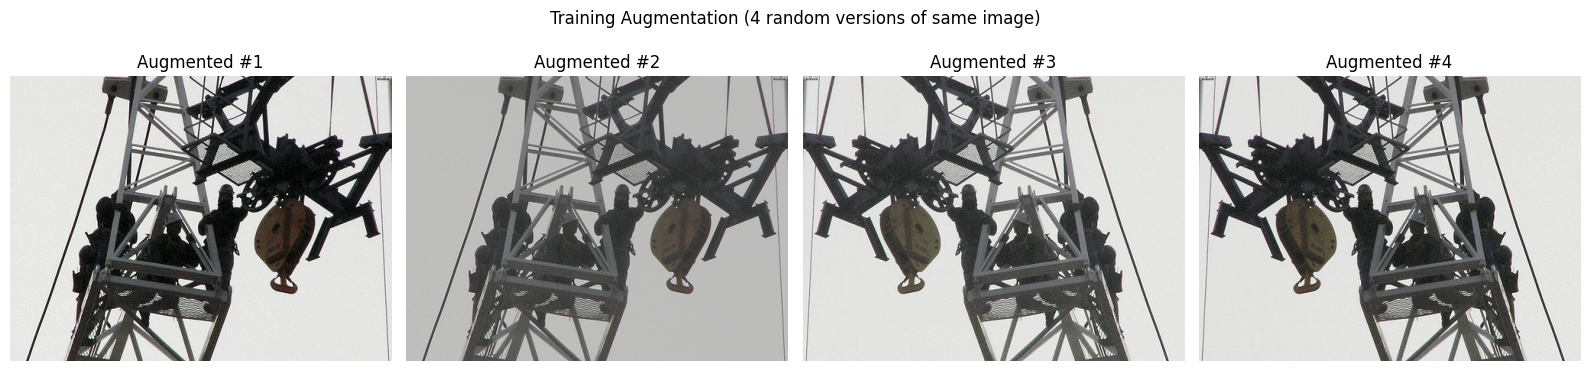

Augmentation pipeline defined.
Applied ONLY to training split. Val/test receive no augmentation.


In [8]:
# ── Training augmentation (applied BEFORE the ViTImageProcessor) ─────────────
# These are torchvision transforms that operate on PIL Images
train_augmentation = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
])

# ── Demonstrate augmentation on the same sample image ─────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Training Augmentation (4 random versions of same image)', fontsize=12)

for i in range(4):
    augmented = train_augmentation(sample_pil)
    axes[i].imshow(augmented)
    axes[i].set_title(f'Augmented #{i+1}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print('Augmentation pipeline defined.')
print('Applied ONLY to training split. Val/test receive no augmentation.')

---
## Section 5 — Text Preprocessing with GPT-2 Tokenizer

### Why GPT-2's tokenizer?
The decision to use GPT-2's tokenizer was made in Notebook 01 based on vocabulary analysis.
GPT-2 uses **Byte-Pair Encoding (BPE)**, which means:
- Every word in the English language can be represented (no `<UNK>` tokens)
- Rare words are split into sub-word pieces: `"parasailing"` → `["par", "asa", "iling"]`
- The tokenizer vocabulary (50,257 tokens) already covers our 15,000-word caption vocabulary

### Special tokens — why we need them
GPT-2 was pretrained as a text completion model with no concept of "start" or "end" of a caption.
We must teach it this structure by adding explicit boundary tokens:

| Token | Meaning | Why it's needed |
|---|---|---|
| `<\|startoftext\|>` | Start of sequence (SOS) | Tells GPT-2 to begin generating a new caption |
| `<\|endoftext\|>` | End of sequence (EOS) | Tells GPT-2 to stop generating — training target |
| `<\|pad\|>` | Padding token | GPT-2 has no padding token by default — batching requires fixed-length sequences |

### Input vs Labels — the autoregressive objective
The model learns by predicting the **next token** at each position:
```
Caption : "A dog runs in a park ."

Input IDs : [SOS,  A,   dog, runs, in,  a,   park,  .,  EOS, PAD, PAD]
Labels    : [ A,  dog, runs, in,   a,  park,  .,   EOS, -100, -100, -100]
                                                         ↑↑↑↑ padding positions
                                                         ignored by loss (=-100)
```
The `-100` label tells PyTorch's `CrossEntropyLoss` to skip those positions,
so the model is never penalised for what it predicts at padding positions.

In [9]:
# ── Load GPT-2 tokenizer ─────────────────────────────────────────────────────
tokenizer = GPT2Tokenizer.from_pretrained(GPT2_MODEL_NAME)

# ── Add the 3 special tokens ─────────────────────────────────────────────────
# Note: GPT-2 already has <|endoftext|> as its EOS token (token id 50256)
# We add <|startoftext|> as BOS and <|pad|> as padding
special_tokens = {
    'bos_token': '<|startoftext|>',
    'eos_token': '<|endoftext|>',
    'pad_token': '<|pad|>'
}
num_added = tokenizer.add_special_tokens(special_tokens)

print(f'GPT-2 tokenizer loaded.')
print(f'  Base vocabulary size : 50,257')
print(f'  Tokens added         : {num_added}')
print(f'  New vocabulary size  : {len(tokenizer)}')
print(f'  BOS token id         : {tokenizer.bos_token_id}  ({tokenizer.bos_token})')
print(f'  EOS token id         : {tokenizer.eos_token_id}  ({tokenizer.eos_token})')
print(f'  PAD token id         : {tokenizer.pad_token_id}  ({tokenizer.pad_token})')

GPT-2 tokenizer loaded.
  Base vocabulary size : 50,257
  Tokens added         : 3
  New vocabulary size  : 50259
  BOS token id         : 50257  (<|startoftext|>)
  EOS token id         : 50256  (<|endoftext|>)
  PAD token id         : 50258  (<|pad|>)


In [10]:
# ── Demonstrate tokenisation on a real caption ───────────────────────────────
sample_caption = train_df['caption'].iloc[0]
full_caption   = f'{tokenizer.bos_token}{sample_caption}{tokenizer.eos_token}'

encoded = tokenizer(
    full_caption,
    max_length    = MAX_LENGTH,
    padding       = 'max_length',
    truncation    = True,
    return_tensors = 'pt'
)

input_ids      = encoded['input_ids'].squeeze(0)
attention_mask = encoded['attention_mask'].squeeze(0)

# Build labels: copy input_ids, then mask padding positions with -100
labels = input_ids.clone()
labels[labels == tokenizer.pad_token_id] = -100

print(f'Original caption  : "{sample_caption}"')
print(f'Token count       : {(input_ids != tokenizer.pad_token_id).sum().item()} real + {(input_ids == tokenizer.pad_token_id).sum().item()} padding = {MAX_LENGTH} total')
print(f'input_ids shape   : {input_ids.shape}')
print(f'labels shape      : {labels.shape}')
print(f'Unique label values: {labels.unique().tolist()[:8]}... (-100 = ignored padding)')
print()
print('Decoded tokens (first 10):')
for tok_id in input_ids[:10]:
    if tok_id.item() == tokenizer.pad_token_id:
        print(f'  {tok_id.item():6d}  →  <PAD>')
    else:
        print(f'  {tok_id.item():6d}  →  {repr(tokenizer.decode([tok_id.item()]))}')

Original caption  : "Several men in hard hats are operating a giant pulley system ."
Token count       : 15 real + 49 padding = 64 total
input_ids shape   : torch.Size([64])
labels shape      : torch.Size([64])
Unique label values: [-100, 257, 287, 389, 764, 1080, 1327, 1450]... (-100 = ignored padding)

Decoded tokens (first 10):
   50257  →  '<|startoftext|>'
   14945  →  'Several'
    1450  →  ' men'
     287  →  ' in'
    1327  →  ' hard'
   23910  →  ' hats'
     389  →  ' are'
    5361  →  ' operating'
     257  →  ' a'
    6175  →  ' giant'


In [11]:
# ── Verify max_length = 64 is sufficient for this dataset ────────────────────
# This validates the decision made in Notebook 01
token_lengths = []
for caption in train_df['caption'].sample(2000, random_state=RANDOM_SEED):
    full = f'{tokenizer.bos_token}{caption}{tokenizer.eos_token}'
    ids  = tokenizer.encode(full, truncation=False)
    token_lengths.append(len(ids))

token_lengths = pd.Series(token_lengths)

print('Token length statistics (BPE tokens, not words, sample of 2000):')
print(token_lengths.describe().round(1))
print(f'\nCaptions fitting in MAX_LENGTH={MAX_LENGTH} : {100*(token_lengths <= MAX_LENGTH).mean():.2f}%')
print(f'Captions that would be truncated         : {(token_lengths > MAX_LENGTH).sum()} / 2000')

Token length statistics (BPE tokens, not words, sample of 2000):
count    2000.0
mean       16.2
std         5.9
min         5.0
25%        12.0
50%        15.0
75%        19.0
max        78.0
dtype: float64

Captions fitting in MAX_LENGTH=64 : 99.95%
Captions that would be truncated         : 1 / 2000


---
## Section 6 — PyTorch Dataset Class (`Flickr30kDataset`)

### Why a custom Dataset class?
PyTorch's `DataLoader` requires data to be wrapped in a `Dataset` subclass.
The `Dataset` must implement:
- `__len__()` → total number of samples
- `__getitem__(idx)` → returns one sample at the given index

Our custom class does the following for each sample:
1. Opens the image file from disk
2. Applies augmentation (training only) → passes through ViTImageProcessor
3. Tokenises the caption → builds input_ids, attention_mask, labels
4. Returns a tuple of tensors ready for the model

### Design decisions
- **All 5 captions per image are used during training** → 5× more training pairs
- **The image path column is used from the split CSV** → no need to re-build paths
- **Error handling** on image open → corrupt images return `None` (DataLoader collation handles it)
- **Split parameter** → same class handles train/val/test by toggling augmentation

In [12]:
class Flickr30kDataset(Dataset):
    """
    PyTorch Dataset for Flickr30k image captioning.

    Returns:
        pixel_values (Tensor): shape (3, 224, 224) — processed image
        input_ids    (Tensor): shape (MAX_LENGTH,) — tokenised caption with SOS/EOS
        attention_mask (Tensor): shape (MAX_LENGTH,) — 1=real token, 0=padding
        labels       (Tensor): shape (MAX_LENGTH,) — same as input_ids but -100 at padding
    """

    def __init__(self, dataframe, processor, tokenizer,
                 max_len=MAX_LENGTH, split='train'):
        """
        Args:
            dataframe  : pandas DataFrame with columns [image, caption, image_path]
            processor  : ViTImageProcessor instance
            tokenizer  : GPT2Tokenizer instance (with SOS/EOS/PAD added)
            max_len    : maximum token length for captions
            split      : 'train' applies augmentation; 'val'/'test' does not
        """
        self.df        = dataframe.reset_index(drop=True)
        self.processor = processor
        self.tokenizer = tokenizer
        self.max_len   = max_len
        self.split     = split

        # Augmentation only for training split
        self.augment = train_augmentation if split == 'train' else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── 1. Load image ────────────────────────────────────────────────────
        image = Image.open(row['image_path']).convert('RGB')

        # ── 2. Apply augmentation (training only) ────────────────────────────
        if self.augment:
            image = self.augment(image)

        # ── 3. Process image with ViTImageProcessor ─────────────────────────
        pixel_values = self.processor(
            images=image, return_tensors='pt'
        )['pixel_values'].squeeze(0)  # remove batch dim → (3, 224, 224)

        # ── 4. Tokenise caption ──────────────────────────────────────────────
        caption    = row['caption']
        full_text  = f'{self.tokenizer.bos_token}{caption}{self.tokenizer.eos_token}'

        encoded = self.tokenizer(
            full_text,
            max_length     = self.max_len,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        input_ids      = encoded['input_ids'].squeeze(0)       # (max_len,)
        attention_mask = encoded['attention_mask'].squeeze(0)  # (max_len,)

        # ── 5. Build labels: -100 at all PAD positions ───────────────────────
        labels = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return pixel_values, input_ids, attention_mask, labels


print('Flickr30kDataset class defined.')

Flickr30kDataset class defined.


Dataset Instantiation & Verification

Creates separate train, validation, and test datasets using the custom Flickr30kDataset class. It then tests one training sample to verify the image tensor, tokenized caption, attention mask, and labels have the correct shapes and data types, while also checking the number of real and padding tokens.

In [13]:
# ── NOTE: num_workers is set to 0 on Windows (see constants cell) ──────────
# Windows multiprocessing 'spawn' re-imports all libraries per worker,
# causing deadlocks with heavy libs like transformers and PIL.
# num_workers=0 runs loading in the main process — fast enough for our dataset.
# On Linux/Mac, num_workers=2 gives a meaningful speedup.

# ── Instantiate datasets for all three splits ─────────────────────────────────
train_dataset = Flickr30kDataset(train_df, processor, tokenizer, split='train')
val_dataset   = Flickr30kDataset(val_df,   processor, tokenizer, split='val')
test_dataset  = Flickr30kDataset(test_df,  processor, tokenizer, split='test')

print(f'Train dataset : {len(train_dataset):,} samples (captions)')
print(f'Val dataset   : {len(val_dataset):,} samples')
print(f'Test dataset  : {len(test_dataset):,} samples')
print()

# ── Test __getitem__ on one sample ────────────────────────────────────────────
pv, ids, mask, lbl = train_dataset[0]
print('Single sample tensor shapes:')
print(f'  pixel_values   : {pv.shape}   dtype={pv.dtype}')
print(f'  input_ids      : {ids.shape}  dtype={ids.dtype}')
print(f'  attention_mask : {mask.shape}  dtype={mask.dtype}')
print(f'  labels         : {lbl.shape}  dtype={lbl.dtype}')
print(f'  Real tokens    : {(ids != tokenizer.pad_token_id).sum().item()}')
print(f'  Padding tokens : {(ids == tokenizer.pad_token_id).sum().item()}')

Train dataset : 149,669 samples (captions)
Val dataset   : 5,270 samples
Test dataset  : 3,975 samples

Single sample tensor shapes:
  pixel_values   : torch.Size([3, 224, 224])   dtype=torch.float32
  input_ids      : torch.Size([64])  dtype=torch.int64
  attention_mask : torch.Size([64])  dtype=torch.int64
  labels         : torch.Size([64])  dtype=torch.int64
  Real tokens    : 15
  Padding tokens : 49


---
## Section 7 — DataLoaders

### Why DataLoaders?
A `DataLoader` wraps a `Dataset` and handles:
- **Batching** → groups `BATCH_SIZE` samples into one tensor
- **Shuffling** → randomises order each epoch (training only — prevents memorisation of order)
- **Parallel loading** → `num_workers` background processes load data while the GPU trains
- **Pin memory** → speeds up CPU→GPU data transfer (only with CUDA)

### Key settings
| Setting | Train | Val/Test | Why |
|---|---|---|---|
| `shuffle` | `True` | `False` | Training benefits from random order; evaluation must be deterministic |
| `num_workers` | 2 | 2 | Background workers to overlap disk I/O with GPU computation |
| `pin_memory` | auto | auto | Faster CPU→GPU if CUDA available |
| `drop_last` | `True` | `False` | Drops the final incomplete batch during training (avoids batch norm issues) |

In [14]:
pin = torch.cuda.is_available()  # pin_memory only helps with CUDA

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,       # randomise order each epoch
    num_workers = NUM_WORKERS,
    pin_memory  = pin,
    drop_last   = True        # drop final partial batch during training
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,      # must be deterministic for evaluation
    num_workers = NUM_WORKERS,
    pin_memory  = pin,
    drop_last   = False
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = pin,
    drop_last   = False
)

print(f'Train DataLoader : {len(train_loader)} batches of {BATCH_SIZE}')
print(f'Val DataLoader   : {len(val_loader)} batches of {BATCH_SIZE}')
print(f'Test DataLoader  : {len(test_loader)} batches of {BATCH_SIZE}')

Train DataLoader : 4677 batches of 32
Val DataLoader   : 165 batches of 32
Test DataLoader  : 125 batches of 32


---
## Section 8 — Batch Shape Sanity Check

### Why this matters
This is the most important verification step in the preprocessing notebook.

Before we write a single line of model code (Notebook 03), we need to confirm:
1. The DataLoader produces tensors of the exact expected shapes
2. The pixel_values range is correct (normalised float, not raw 0–255)
3. The input_ids are valid token ids (all < vocabulary size)
4. The labels have -100 at padding positions

**If any of these checks fail here, the model will silently produce wrong results.**
Debugging shape mismatches inside the training loop is much harder than catching them here.

These exact shapes are the **input contract** that Notebook 03 must design the model to accept:
- `pixel_values`: `(32, 3, 224, 224)` → ViT encoder input
- `input_ids`:    `(32, 64)`          → GPT-2 decoder input  
- `labels`:       `(32, 64)`          → CrossEntropy target

In [15]:
# ── Pull one batch and verify every dimension ─────────────────────────────────
batch_pv, batch_ids, batch_mask, batch_labels = next(iter(train_loader))

print('=' * 55)
print('BATCH SHAPE VERIFICATION')
print('=' * 55)
print(f'pixel_values   shape : {batch_pv.shape}')
print(f'               dtype : {batch_pv.dtype}')
print(f'               range : [{batch_pv.min():.3f}, {batch_pv.max():.3f}]')
print()
print(f'input_ids      shape : {batch_ids.shape}')
print(f'               dtype : {batch_ids.dtype}')
print(f'               max id: {batch_ids.max().item()} (vocab size = {len(tokenizer)})')
print()
print(f'attention_mask shape : {batch_mask.shape}')
print(f'               unique values: {batch_mask.unique().tolist()}')
print()
print(f'labels         shape : {batch_labels.shape}')
print(f'               unique values (first 10): {batch_labels.unique()[:10].tolist()}')
print(f'               -100 positions: {(batch_labels == -100).sum().item()} / {batch_labels.numel()}')
print()

# ── Automated assertions — these will raise errors if anything is wrong ──────
assert batch_pv.shape    == (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE), f'pixel_values shape wrong: {batch_pv.shape}'
assert batch_ids.shape   == (BATCH_SIZE, MAX_LENGTH), f'input_ids shape wrong: {batch_ids.shape}'
assert batch_mask.shape  == (BATCH_SIZE, MAX_LENGTH), f'attention_mask shape wrong: {batch_mask.shape}'
assert batch_labels.shape == (BATCH_SIZE, MAX_LENGTH), f'labels shape wrong: {batch_labels.shape}'
assert batch_ids.max().item() < len(tokenizer), 'Token ID exceeds vocabulary size!'
assert -100 in batch_labels, 'No -100 labels found — label masking may have failed!'

print('All assertions passed. Data pipeline is correct.')
print('These shapes are the INPUT CONTRACT for Notebook 03 (model architecture).')

BATCH SHAPE VERIFICATION
pixel_values   shape : torch.Size([32, 3, 224, 224])
               dtype : torch.float32
               range : [-1.000, 1.000]

input_ids      shape : torch.Size([32, 64])
               dtype : torch.int64
               max id: 50258 (vocab size = 50259)

attention_mask shape : torch.Size([32, 64])
               unique values: [0, 1]

labels         shape : torch.Size([32, 64])
               unique values (first 10): [-100, 32, 64, 65, 257, 262, 263, 277, 281, 284]
               -100 positions: 1602 / 2048

All assertions passed. Data pipeline is correct.
These shapes are the INPUT CONTRACT for Notebook 03 (model architecture).


---
## Section 9 — Preprocessing Summary

### What this notebook produced

| Output | Location | Used by |
|---|---|---|
| `train.csv` | `src/data/train.csv` | Notebooks 03, 04 |
| `val.csv`   | `src/data/val.csv`   | Notebooks 04, 05 |
| `test.csv`  | `src/data/test.csv`  | Notebook 05 |
| `Flickr30kDataset` class | This notebook (import in 04) | Notebook 04 |
| DataLoaders (train/val/test) | This notebook (import in 04) | Notebook 04 |

### Data contract confirmed
```
Input to VisionNarrator model (per batch of 32):
  pixel_values   : (32, 3, 224, 224)  float32  — ViT encoder input
  input_ids      : (32, 64)           int64    — GPT-2 decoder input
  attention_mask : (32, 64)           int64    — 1=real, 0=pad
  labels         : (32, 64)           int64    — targets (-100 at padding)
```

### Next: Notebook 03 — Model Architecture
The model notebook will:
1. Load `google/vit-base-patch16-224-in21k` and feed it `pixel_values (32, 3, 224, 224)` 
2. Get back image features of shape `(32, 197, 768)` — 197 = 196 patches + 1 CLS token
3. Project those features through a `Linear(768, 768)` layer
4. Concatenate with GPT-2 token embeddings → run through GPT-2 → get loss

> **Preprocessing Complete ✅**